<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-001.png" class="img-responsive"/>
</div>

In [ ]:
def mat_mult(m1, m2):
    m_out = [[0] * len(m2[0]) for _ in m1]

    return m_out

print(mat_mult([[3, 3], [2, 2], [1, 1]], [[2], [3]]))


[[15], [10], [5]]


<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-002.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-003.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-005.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-006.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-007.png" class="img-responsive"/>
</div>

device: cuda
train subset size: 1024


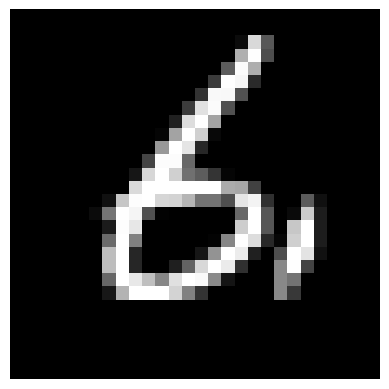

tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], device='cuda:0')


In [ ]:
# @title Data Loader
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -----------------------------
# 1) Data (RANDOM subset)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# ----- KEY PART: RANDOM SUBSET -----
N_TRAIN = 1024  # size of subset

# make it reproducible for teaching (change/remove seed if you want new samples)
random.seed(42)

all_indices = list(range(len(train_full)))
random.shuffle(all_indices)
subset_indices = all_indices[:N_TRAIN]

train_ds = Subset(train_full, subset_indices)

# -----------------------------------

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

example_img = train_ds[0][0].to(device)
example_expected = torch.nn.functional.one_hot(torch.tensor(train_ds[0][1]), num_classes=10).float().unsqueeze(0).to(device)

print("train subset size:", len(train_ds))

plt.figure()
plt.imshow(example_img.cpu().squeeze(), cmap="gray")
plt.axis("off")
plt.show()

print(example_expected)

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-008.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-010.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture09/slide-011.png" class="img-responsive"/>
</div>

In [ ]:
# @title Linear Layer

class LinearLayer():
    def __init__(self, in_dim, out_dim):
        self.W = (0.01 * torch.randn(out_dim, in_dim, device=device))
        self.b = torch.zeros(1, out_dim, device=device)

    def forward(self, x_batch):
        self.x_batch = x_batch

        return x_batch @ self.W.T + self.b

    def backward(self, dA, lr):
        dW = dA.T @ self.x_batch
        db = dA.sum(dim=0, keepdims=True)

        self.W -= lr * dW
        self.b -= lr * db

In [ ]:
# @title Evaluation Function
@torch.no_grad()
def evaluate(loader, linear_layer, device='cpu'):
    total_loss, correct, seen = 0.0, 0, 0
    for x, y in loader:
        x_test = torch.flatten(x.squeeze(1).to(device), start_dim=1)
        y_test = torch.nn.functional.one_hot(y, num_classes=10).float().to(device)

        logits = linear_layer.forward(x_test)
        loss = F.cross_entropy(logits, y_test)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y_test.argmax(dim=1)).sum().item()
        seen += x.size(0)

    return total_loss / seen, correct / seen

In [ ]:
# @title Training Loop

lr = 0.001
epochs = 25

train_losses, train_accs = [], []
test_losses, test_accs = [], []
example_losses = []

linear_layer = LinearLayer(784, 10)

example_img = torch.flatten(example_img, start_dim=1)

print(f"[epoch 0]")
example_prediction_probs = torch.nn.functional.softmax(linear_layer.forward(example_img), dim=1).tolist()[0]
print(f'\tPrediction for example image:', [f'{x:.4f}' for x in example_prediction_probs])
print(f'\tExpected for example image:  ', [f'{x:.4f}' for x in example_expected[0].tolist()])
example_losses.append(F.cross_entropy(linear_layer.forward(example_img), example_expected).tolist())
print(f'\tLoss for example image:', round(example_losses[-1], 4))

for epoch in range(1, epochs + 1):
    total_loss, correct, seen = 0.0, 0, 0

    x_train, y_train = next(iter(train_loader))
    x_train = torch.flatten(x_train.squeeze(1).to(device), start_dim=1)
    y_train = torch.nn.functional.one_hot(y_train, num_classes=10).float().to(device)

    logits = linear_layer.forward(x_train)
    loss = F.cross_entropy(logits, y_train)

    # Differentiate L with respect to w
    log_probs = logits - logits.logsumexp(dim=1, keepdim=True)
    Y_hat = log_probs.exp()

    dA = Y_hat - y_train

    # Update our weights
    linear_layer.backward(dA, lr)

    acc = (logits.argmax(dim=1) == y_train.argmax(dim=1)).float().mean().item()

    train_losses.append(loss.item())
    te_loss, te_acc = evaluate(test_loader, linear_layer, device)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(f"[epoch {epoch:02d}] test loss={te_loss:.4f} test acc={te_acc*100:.2f}%")
    example_losses.append(F.cross_entropy(linear_layer.forward(example_img), example_expected).tolist())
    print(f'\tLoss for example image:', round(example_losses[-1], 4))

[epoch 0]
	Prediction for example image: ['0.1123', '0.0794', '0.0757', '0.0733', '0.1454', '0.1060', '0.1127', '0.0827', '0.1047', '0.1079']
	Expected for example image:   ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000']
	Loss for example image: 2.1829
[epoch 01] test loss=2.0592 test acc=36.88%
	Loss for example image: 1.4848
[epoch 02] test loss=1.8091 test acc=42.88%
	Loss for example image: 1.8458
[epoch 03] test loss=1.6923 test acc=42.10%
	Loss for example image: 2.2373
[epoch 04] test loss=1.4682 test acc=54.40%
	Loss for example image: 2.16
[epoch 05] test loss=1.3532 test acc=62.64%
	Loss for example image: 2.1586
[epoch 06] test loss=1.2521 test acc=64.37%
	Loss for example image: 1.5719
[epoch 07] test loss=1.2215 test acc=63.85%
	Loss for example image: 1.6507
[epoch 08] test loss=1.0895 test acc=69.99%
	Loss for example image: 1.7273
[epoch 09] test loss=1.0225 test acc=73.02%
	Loss for example image: 1.0998
[epoch 10] t

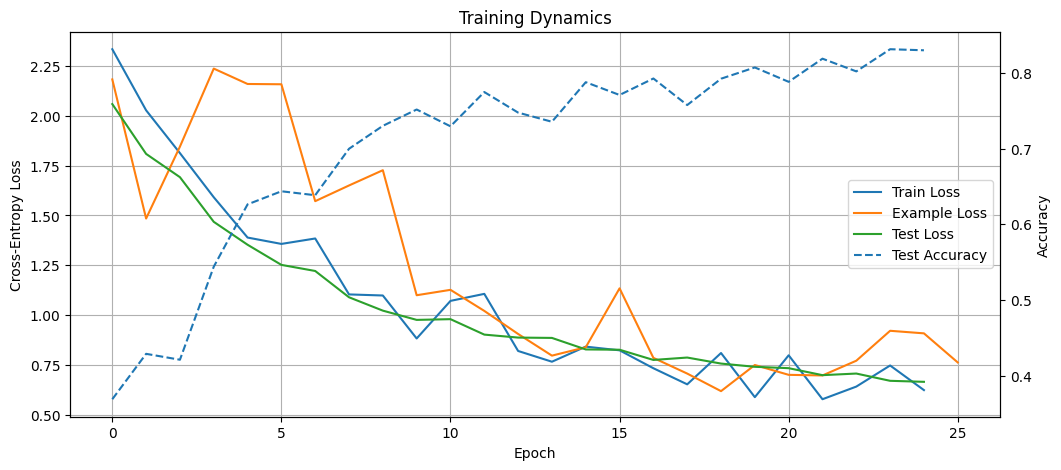

In [ ]:
# @title Training Dynamics Grapher
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))

# --- Left axis: Loss ---
ax1.plot(train_losses, label="Train Loss")
ax1.plot(example_losses, label="Example Loss")
ax1.plot(test_losses, label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True)

# --- Right axis: Accuracy ---
ax2 = ax1.twinx()
ax2.plot(test_accs, label="Test Accuracy", linestyle="dashed")
ax2.set_ylabel("Accuracy")

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right")

plt.title("Training Dynamics")
plt.show()